<div style="background-color:#ffe6f0; padding:18px; border-radius:12px; border:1px solid #ffb3d1; color:#1a1a1a;">

<h3 style="color:#cc0066; margin-top:0;">🌸 Aplicación astronómica: Pulsación radial de una estrella</h3>



Primeros valores:
t = 0.000, x(t) = 0.010000, R(t) = 1.010000
t = 0.020, x(t) = 0.009992, R(t) = 1.009992
t = 0.040, x(t) = 0.009968, R(t) = 1.009968
t = 0.060, x(t) = 0.009929, R(t) = 1.009929
t = 0.080, x(t) = 0.009874, R(t) = 1.009874
t = 0.100, x(t) = 0.009803, R(t) = 1.009803
t = 0.120, x(t) = 0.009718, R(t) = 1.009718
t = 0.140, x(t) = 0.009618, R(t) = 1.009618
t = 0.160, x(t) = 0.009503, R(t) = 1.009503
t = 0.180, x(t) = 0.009374, R(t) = 1.009374


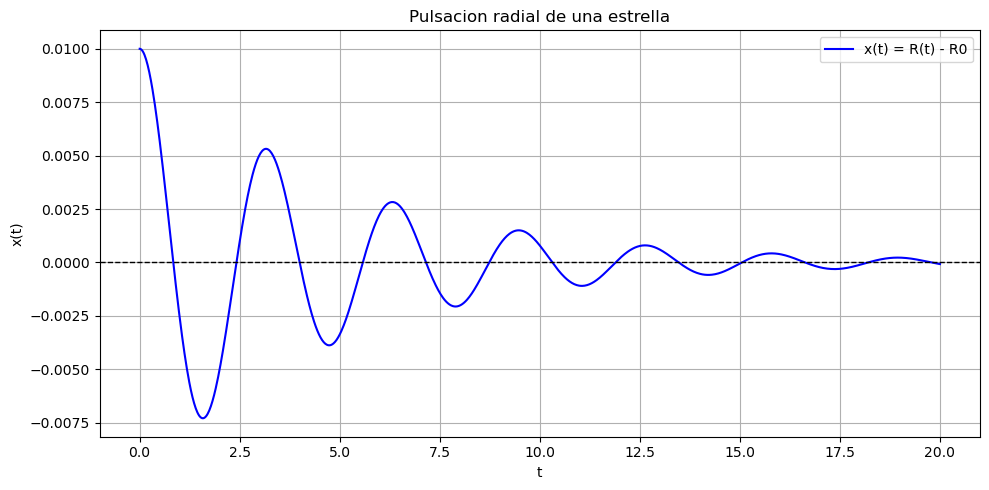

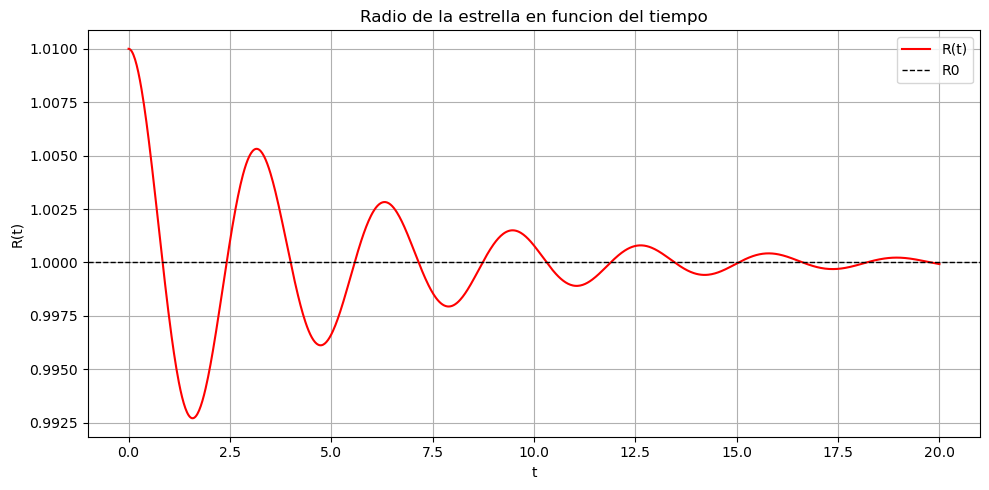

In [3]:
import numpy as np
import matplotlib.pyplot as plt



# Datos 
R0 = 1.0          # radio medio
omega0 = 2.0      # frecuencia natural
xi = 0.2          # amortiguamiento

t0 = 0.0
tf = 20.0
N = 1000
h = (tf - t0) / N

# Condiciones iniciales
x0 = 0.01 * R0    # x(0)
v0 = 0.0          # x'(0)

# Sistema equivalente
# y1 = x
# y2 = x'
def f(t, y):
    x = y[0]
    v = y[1]

    dxdt = v
    dvdt = -omega0 * xi * v - (omega0 ** 2) * x

    return np.array([dxdt, dvdt])

# Seleccione el metodo de Runge-Kutta 4

def rk4(t0, tf, y0, N):
    h = (tf - t0) / N
    t_values = np.zeros(N + 1)
    y_values = np.zeros((N + 1, len(y0)))

    t_values[0] = t0
    y_values[0] = y0

    for i in range(N):
        t = t_values[i]
        y = y_values[i]

        k1 = f(t, y)
        k2 = f(t + h / 2, y + h * k1 / 2)
        k3 = f(t + h / 2, y + h * k2 / 2)
        k4 = f(t + h, y + h * k3)

        y_values[i + 1] = y + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        t_values[i + 1] = t + h

    return t_values, y_values


# Resolver
y0 = np.array([x0, v0])
t, y = rk4(t0, tf, y0, N)

x = y[:, 0]          # desviacion del radio
v = y[:, 1]          # velocidad
R = R0 + x           # radio total de la estrella

# Mostrar algunos resultados
print("Primeros valores:")
for i in range(10):
    print(f"t = {t[i]:.3f}, x(t) = {x[i]:.6f}, R(t) = {R[i]:.6f}")

# Graficas
plt.figure(figsize=(10, 5))
plt.plot(t, x, label="x(t) = R(t) - R0", color="blue")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Pulsacion radial de una estrella")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(t, R, label="R(t)", color="red")
plt.axhline(R0, color="black", linestyle="--", linewidth=1, label="R0")
plt.xlabel("t")
plt.ylabel("R(t)")
plt.title("Radio de la estrella en funcion del tiempo")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


<div style="background-color:#ffe6f0; padding:18px; border-radius:12px; border:1px solid #ffb3d1; color:#1a1a1a;">

<h3 style="color:#cc0066; margin-top:0;">🌸 Interpretación de la pulsación estelar</h3>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
Para resolver el problema, básicamente reescribí la ecuación de segundo orden como un sistema de dos ecuaciones de primer orden y la resolví numéricamente con Runge-Kutta de cuarto orden, porque es mucho más preciso que Euler.
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
Al graficar la solución se ve claramente un comportamiento oscilatorio amortiguado: la estrella se expande y se contrae alrededor de un radio de equilibrio, pero cada vez lo hace con menor amplitud.
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
En este modelo:
</p>

<ul style="color:#1a1a1a; font-size:15px; margin:0 0 10px 20px;">
<li>\( \omega_0 \) representa la frecuencia natural de la pulsación</li>
<li>\( \xi \) controla qué tan rápido se amortiguan las oscilaciones</li>
</ul>

<p style="color:#1a1a1a; font-size:15px; margin:0;">
En conclusión, si se perturba el radio de la estrella, esta responde oscilando, pero con el tiempo esas oscilaciones se van apagando hasta volver al equilibrio.
</p>

</div>

<div style="background-color:#ffe6f0; padding:18px; border-radius:12px; border:1px solid #ffb3d1; color:#1a1a1a;">

<h3 style="color:#cc0066; margin-top:0;">🌸 Transformación del sistema, solución con RK4 y gráficas de la pulsación radial</h3>

RESPUESTA a)
Sistema de primer orden:
x'(t) = v(t)
v'(t) = -omega0*xi*v(t) - omega0^2*x(t)

RESPUESTA b)
Metodo usado: Runge-Kutta de 4to orden (RK4)
Paso usado: h = 0.01
Condiciones iniciales: x(0) = 0.01, v(0) = 0.0

Primeros 10 valores:
t = 0.00, x(t) = 0.010000, v(t) = 0.000000
t = 0.01, x(t) = 0.009998, v(t) = -0.000399
t = 0.02, x(t) = 0.009992, v(t) = -0.000797
t = 0.03, x(t) = 0.009982, v(t) = -0.001192
t = 0.04, x(t) = 0.009968, v(t) = -0.001586
t = 0.05, x(t) = 0.009950, v(t) = -0.001977
t = 0.06, x(t) = 0.009929, v(t) = -0.002366
t = 0.07, x(t) = 0.009903, v(t) = -0.002752
t = 0.08, x(t) = 0.009874, v(t) = -0.003136
t = 0.09, x(t) = 0.009840, v(t) = -0.003517

RESPUESTA c)
Se grafican x(t) y v(t) para observar las oscilaciones amortiguadas.



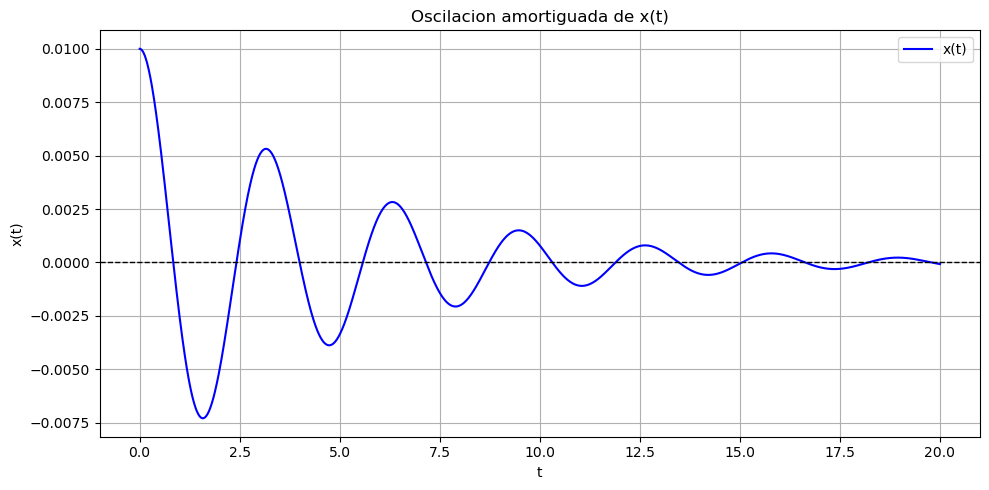

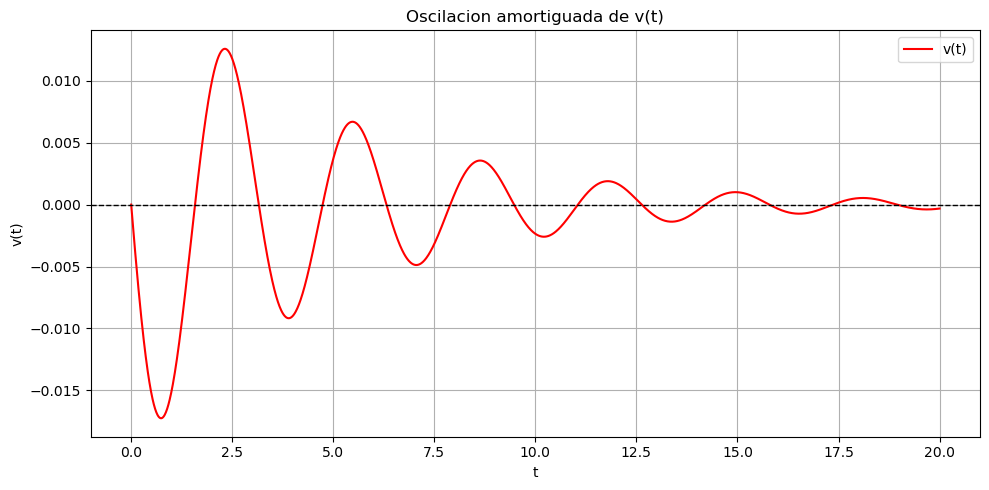

In [5]:
import numpy as np
import matplotlib.pyplot as plt


# datos iniciales
R0 = 1.0
omega0 = 2.0
xi = 0.2

# Condiciones iniciales
x0 = 0.01 * R0
v0 = 0.0

# Intervalo de tiempo y paso
t0 = 0.0
tf = 20.0
h = 0.01

# a) TRANSFORMAR LA ODE DE ORDEN 2 A DOS ODES DE ORDEN 1

def f(t, y):
    x = y[0]
    v = y[1]

    dxdt = v
    dvdt = -omega0 * xi * v - (omega0 ** 2) * x

    return np.array([dxdt, dvdt])

# b) RESOLVER USANDO RK4 CON h = 0.01
def rk4_system(f, t0, tf, y0, h):
    n_steps = int((tf - t0) / h)

    t_values = np.zeros(n_steps + 1)
    y_values = np.zeros((n_steps + 1, len(y0)))

    t_values[0] = t0
    y_values[0] = y0

    for i in range(n_steps):
        t = t_values[i]
        y = y_values[i]

        k1 = f(t, y)
        k2 = f(t + h / 2, y + (h / 2) * k1)
        k3 = f(t + h / 2, y + (h / 2) * k2)
        k4 = f(t + h, y + h * k3)

        y_values[i + 1] = y + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        t_values[i + 1] = t + h

    return t_values, y_values


# Resolver el sistema
y0 = np.array([x0, v0])
t, y = rk4_system(f, t0, tf, y0, h)

x = y[:, 0]
v = y[:, 1]

# MOSTRAR RESPUESTA DE a) Y b)
print("========================================")
print("RESPUESTA a)")
print("========================================")
print("Sistema de primer orden:")
print("x'(t) = v(t)")
print("v'(t) = -omega0*xi*v(t) - omega0^2*x(t)")
print()

print("========================================")
print("RESPUESTA b)")
print("========================================")
print("Metodo usado: Runge-Kutta de 4to orden (RK4)")
print(f"Paso usado: h = {h}")
print(f"Condiciones iniciales: x(0) = {x0}, v(0) = {v0}")
print()

print("Primeros 10 valores:")
for i in range(10):
    print(f"t = {t[i]:.2f}, x(t) = {x[i]:.6f}, v(t) = {v[i]:.6f}")
print()

# c) GRAFICAR x(t) Y v(t)

print("========================================")
print("RESPUESTA c)")
print("========================================")
print("Se grafican x(t) y v(t) para observar las oscilaciones amortiguadas.")
print()

plt.figure(figsize=(10, 5))
plt.plot(t, x, color="blue", label="x(t)")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Oscilacion amortiguada de x(t)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(t, v, color="red", label="v(t)")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("t")
plt.ylabel("v(t)")
plt.title("Oscilacion amortiguada de v(t)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


<div style="background-color:#ffe6f0; padding:18px; border-radius:12px; border:1px solid #ffb3d1; color:#1a1a1a;">

<h3 style="color:#cc0066; margin-top:0;">🌸 Aplicación astronómica: pulsación radial de una estrella</h3>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
Partí de la ecuación de segundo orden que describe la pulsación de la estrella:
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
\[
x''(t) + \omega_0 \,\xi \, x'(t) + \omega_0^2 \, x(t) = 0
\]
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
Para poder resolverla numéricamente, la pasé a un sistema de primer orden definiendo \( v(t) = x'(t) \). Con eso, el sistema queda:
</p>

<ul style="color:#1a1a1a; font-size:15px; margin:0 0 10px 20px;">
<li>\( x'(t) = v(t) \)</li>
<li>\( v'(t) = -\omega_0 \,\xi \, v(t) - \omega_0^2 \, x(t) \)</li>
</ul>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
Luego resolví este sistema con Runge-Kutta de cuarto orden (RK4), usando un paso \( h = 0.01 \) y las condiciones iniciales:
</p>

<ul style="color:#1a1a1a; font-size:15px; margin:0 0 10px 20px;">
<li>\( x(0) = 0.01\,R_0 \)</li>
<li>\( v(0) = 0 \)</li>
</ul>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
Con esto obtuve la evolución de \( x(t) \) y \( v(t) \) en el tiempo.
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
Al graficar, se ve un comportamiento oscilatorio amortiguado: la estrella se expande y se contrae alrededor de su radio de equilibrio, pero cada vez con menor amplitud.
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0;">
Esto es justo lo que se espera físicamente en estrellas pulsantes, donde una perturbación inicial genera oscilaciones que se van apagando con el tiempo.
</p>

</div>